In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer
from models.whitener import Whitener

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
    'whitener': Whitener(64, 0.0),
}

In [2]:
paths = [
    'runs/whitened/regw3_seed0/model_weights.pth',
    'runs/whitened/regw3_seed42/model_weights.pth',
    'runs/whitened/regw3_seed123/model_weights.pth',
]

# paths = [
#     'runs/newbase/dim64_seed0/model_weights.pth',
#     'runs/newbase/dim64_seed42/model_weights.pth',
#     'runs/newbase/dim64_seed123/model_weights.pth',
# ]

In [3]:
num_batches = 5
Xs_train = []
Xs_val = []

for path in paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device);
    model.core.train();
    model.readout.eval();

    train_feature_vecs = []
    val_feature_vecs = []

    for key in data_keys:
        batch_count = 0
        for batch in dataloaders['train'][key]:
            batch_count += 1
            img, _, _, pupil = batch
            
            pred, feature_vec = model(img, data_key=key, pupil_center=pupil, return_vec=True)
            train_feature_vecs.append(feature_vec.detach().cpu().transpose(1, 3).flatten(0, 2))

            if batch_count == num_batches:
                break

        batch_count = 0
        for batch in dataloaders['validation'][key]:
            batch_count += 1
            img, _, _, pupil = batch
            
            pred, feature_vec = model(img, data_key=key, pupil_center=pupil, return_vec=True)
            val_feature_vecs.append(feature_vec.detach().cpu().transpose(1, 3).flatten(0, 2))
            
            if batch_count == num_batches:
                break


    # whiten based on feature maps
    X_train = torch.cat(train_feature_vecs)
    Xs_train.append(X_train)

    # whiten based on feature maps
    X_val = torch.cat(val_feature_vecs)
    Xs_val.append(X_val)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [4]:
from sensorium.utility import get_correlations
get_correlations(model, dataloaders['validation'], device=device, per_neuron=False)

np.float32(0.39524022)

In [5]:
import torch


def train_val_svcca(
    train_acts1,
    train_acts2,
    val_acts1,
    val_acts2,
    var_thresh=0.99,
):
    """
    SVCCA with train/val split.

    Args:
        train_acts1: [C1, N_train]
        train_acts2: [C2, N_train]
        val_acts1:   [C1, N_val]
        val_acts2:   [C2, N_val]
        var_thresh: variance explained threshold

    Returns:
        cca_corrs: canonical correlations on validation data
        info: dict with retained dimensions and train means
    """

    # --------------------------------------------------
    # 1. Center training activations
    # --------------------------------------------------
    mean1 = train_acts1.mean(dim=1, keepdim=True)
    mean2 = train_acts2.mean(dim=1, keepdim=True)

    train1 = train_acts1 - mean1
    train2 = train_acts2 - mean2

    # --------------------------------------------------
    # 2. Train SVD
    # --------------------------------------------------
    U1, S1, _ = torch.linalg.svd(train1, full_matrices=False)
    U2, S2, _ = torch.linalg.svd(train2, full_matrices=False)

    # --------------------------------------------------
    # 3. Variance threshold (use S^2)
    # --------------------------------------------------
    var1 = torch.cumsum(S1**2, dim=0) / torch.sum(S1**2)
    var2 = torch.cumsum(S2**2, dim=0) / torch.sum(S2**2)

    k1 = int(torch.searchsorted(var1, var_thresh).item()) + 1
    k2 = int(torch.searchsorted(var2, var_thresh).item()) + 1

    U1 = U1[:, :k1]
    U2 = U2[:, :k2]

    # --------------------------------------------------
    # 4. Center validation using TRAIN means
    # --------------------------------------------------
    val1 = val_acts1 - mean1
    val2 = val_acts2 - mean2

    # --------------------------------------------------
    # 5. Project validation into train PCA subspaces
    # --------------------------------------------------
    val1_proj = U1.T @ val1      # [k1, N_val]
    val2_proj = U2.T @ val2      # [k2, N_val]

    # --------------------------------------------------
    # 6. CCA shortcut
    # --------------------------------------------------
    #
    # Whitening via QR gives orthonormal row spaces.
    # Canonical correlations are singular values of
    # the overlap matrix.
    #
    Q1, _ = torch.linalg.qr(val1_proj.T, mode="reduced")
    Q2, _ = torch.linalg.qr(val2_proj.T, mode="reduced")

    cca_corrs = torch.linalg.svdvals(Q1.T @ Q2)

    return cca_corrs, {
        "k1": k1,
        "k2": k2,
        "mean1": mean1,
        "mean2": mean2,
    }

In [6]:
results = train_val_svcca(Xs_train[0].T, Xs_train[1].T, Xs_val[0].T, Xs_val[1].T)

In [13]:
results1 = train_val_svcca(Xs_train[0].T, Xs_train[2].T, Xs_val[0].T, Xs_val[2].T)

In [14]:
results2 = train_val_svcca(Xs_train[1].T, Xs_train[2].T, Xs_val[1].T, Xs_val[2].T)

In [19]:
cca_corrs = torch.stack([results[0], results1[0][:63], results2[0]])
m = cca_corrs.mean(dim=0)
s = cca_corrs.std(dim=0)

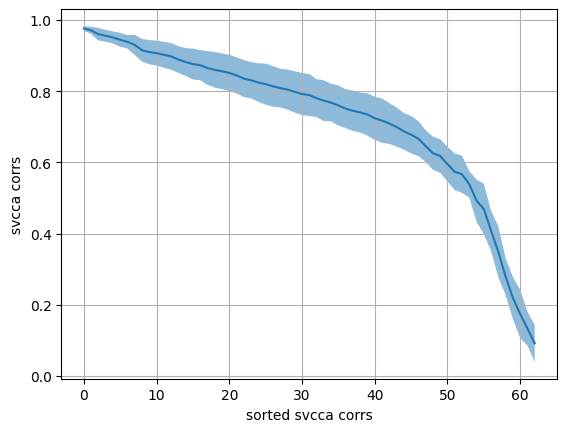

In [23]:
plt.plot(m)
plt.fill_between(range(63), m-s, m+s, alpha=0.5)
plt.xlabel('sorted svcca corrs')
plt.ylabel('svcca corrs')
plt.grid()
plt.show()